In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix,roc_curve, auc
from transformers import AutoTokenizer
from transformers import TFAutoModelForSequenceClassification
from sklearn.utils.class_weight import compute_class_weight

In [2]:
print(tf.__version__)

2.18.0


In [3]:
train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")

In [4]:
X_train, y_train = train["clean_text"].values, train["HATEFUL"].values
X_test, y_test = test["clean_text"].values, test["HATEFUL"].values

In [22]:
model_name = "dccuchile/bert-base-spanish-wwm-uncased"
num_classes = 2
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [23]:
max_length= 64
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True,max_length=max_length)
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length = max_length)

In [24]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test
))

In [25]:
model_cw = TFAutoModelForSequenceClassification.from_pretrained(model_name,num_labels = num_classes)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['classifier', 'bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

In [28]:
opt = tf.keras.optimizers.Adam(learning_rate = 3e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
model_cw.compile(optimizer = opt, loss = loss, metrics = ["accuracy"])

In [29]:
history_cw = model_cw.fit(train_dataset.batch(64),
          epochs=5,
          validation_data=test_dataset.batch(64),
          class_weight=class_weights)

Epoch 1/5
485/485 [==============================] - 493s 923ms/step - loss: 0.5349 - accuracy: 0.7549 - val_loss: 0.4701 - val_accuracy: 0.8285
Epoch 2/5
485/485 [==============================] - 444s 915ms/step - loss: 0.3733 - accuracy: 0.8493 - val_loss: 0.4066 - val_accuracy: 0.8381
Epoch 3/5
485/485 [==============================] - 443s 914ms/step - loss: 0.2478 - accuracy: 0.9014 - val_loss: 0.4410 - val_accuracy: 0.8230
Epoch 4/5
485/485 [==============================] - 444s 915ms/step - loss: 0.1703 - accuracy: 0.9312 - val_loss: 0.6443 - val_accuracy: 0.7813
Epoch 5/5
485/485 [==============================] - 443s 915ms/step - loss: 0.1368 - accuracy: 0.9457 - val_loss: 0.5515 - val_accuracy: 0.8518


In [30]:
y_pred_cw = tf.argmax(model_cw.predict(test_dataset.batch(64)).logits, axis=1)

262/262 [==============================] - 75s 277ms/step


In [31]:
print(classification_report(y_test, y_pred_cw))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91     14146
           1       0.51      0.70      0.59      2567

    accuracy                           0.85     16713
   macro avg       0.73      0.79      0.75     16713
weighted avg       0.88      0.85      0.86     16713



In [33]:
logits = model_cw.predict(test_dataset.batch(64)).logits
probabilities = tf.nn.softmax(logits).numpy()
y_scores = probabilities[:, 1]

262/262 [==============================] - 73s 278ms/step


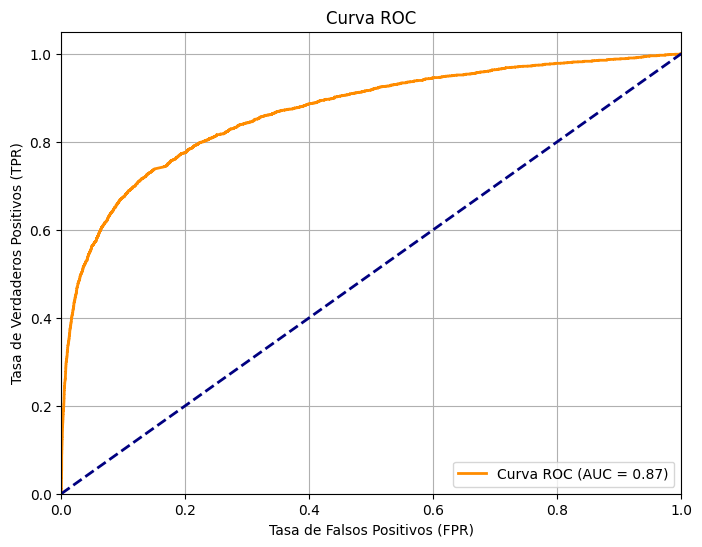

In [34]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
